## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Team list and Credits:

Mohan Dong: Project administration, Data curation, Conceptualization, Software, Writing - review & editing.

James Bartelloni: Methodology, Experimental investigation, Conceptualization, Writing - original draft.

Emily Vega: Conceptualization, Background Research, Writing - original draft, Writing - review & editing.

Nalin Joshi: Data curation, Software, Conceptualization, Writing - original draft.

Alexis Garcia: Methodology, Expiremental investigation, Writing = review & editing.

# Research Question

How did the acoustic characteristics of popular music change from the pre-COVID period (2017–2019) to the post-COVID period (2022), and are shifts in mainstream genre popularity associated with measurable changes in audio signal features such as spectral centroid (brightness), spectral rolloff (high-frequency energy), and zero crossing rate (percussiveness)?

## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


We hypothesize that the acoustic properties of popular music shifted following the COVID-19 pandemic. Specifically, we expect that songs released in the post-COVID period (2022) will exhibit higher spectral centroid, spectral rolloff, and zero crossing rate values compared to songs from the pre-COVID period (2017–2019).

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [88]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  3.06it/s]

Successfully downloaded: airline-safety.csv


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  2.91it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1: Billboard Top 50 Singles Data & Audio Features (1973-2022)

This dataset contains the Billboard Top-50 singles for each year from 1973 to 2022 along with nine audio signal features extracted directly from the waveform of each song. Because the dataset links chart popularity with measurable sound characteristics, it is well suited for studying how the acoustic character of mainstream music changes across time periods such as pre- and post-COVID.

Each observation corresponds to one song in the year-end chart and includes numerical descriptors derived from digital signal processing. Unlike subjective metadata like genre labels, these variables quantify the physical properties of sound.

The variables are standardized signal-analysis measures computed from amplitude and frequency distributions. They correspond closely to human perception of music:
- Chroma STFT (Short-Time Fourier Transform): compresses audio into 12 bins representing the Western chromatic scale (C, C#, D...), regardless of octave. It calculates the energy distribution of pitch classes over time and captures harmonic progression and melody.
- Chroma CENS (Chroma Energy Normalized Statistics): refines the result of standard Chroma STFT to make data robust, smoothed, and suitable for tasks like audio matching, synchronization, and structure analysis. Usually used in comparing musical passages even when they differ in performance style, instrumentation, etc.
- RMSE (Root Mean Square Energy) – Measures average loudness/intensity of the track. Higher values indicate louder, more energetic songs. For listeners this corresponds to musical “power” or punch.
- Spectral Centroid – Represents where most frequency energy is located (low vs high frequencies). Lower values sound darker or warmer, while higher values sound brighter and sharper.
- Spectral Rolloff – Frequency below which most sound energy lies. Higher rolloff suggests more treble/high-frequency content and is often associated with energetic or modern production.
- Spectral Bandwidth – Spread of frequencies present in the audio. Larger bandwidth indicates fuller, richer instrumentation.
- Zero Crossing Rate (ZCR) – Measures how frequently the waveform changes sign. Higher values indicate more percussive or noisy sounds (e.g., electronic or heavily rhythmic tracks).
- MFCC (Mel Frequency Cepstral Coefficients) – A compact representation of timbre (“sound color”), distinguishing acoustic vs electronic textures.
- Spectral Contrast – Difference between harmonic tones and noise components, related to clarity vs distortion.

In practical terms, increases in centroid, rolloff, bandwidth, ZCR, and RMSE generally correspond to music that sounds brighter, more energetic, richer, more dynamic, and louder; while decreases correspond to softer or more mellow sound characteristics. As we focuses on the mood or emotion-related acoustic character, we focus on Spectral Centroid (brightness), Spectral Rolloff (pitch-energy), and Zero Crossing Rate (dynamic and percussion) in this project as they best reflect the brightness and dynamics of a music.

Although the dataset contains many years of music, it only includes the Top-50 most popular songs each year. Therefore, it represents mainstream commercial music rather than all music produced during that period. Niche genres and underground artists are excluded, meaning conclusions should be interpreted as describing popular music trends rather than a universal musical trend.

Another concern is that audio features are derived algorithmically from recordings rather than listener perception. For example, a song may feel emotionally positive due to lyrics or cultural links, but the dataset only captures acoustic properties. Thus the dataset measures sound characteristics, not full emotional meaning.

Additionally, production technology evolves over decades: recording quality, mastering techniques, and compression may improve every year. Some feature differences may therefore reflect improvements in recording technology rather than cultural preference. This is particularly important when comparing modern post-COVID songs to older tracks.

Finally, the dataset ignores listening frequency, streaming counts, and regional variation. A highly streamed song and a barely-ranked #50 song are treated equally, which may reduce sensitivity when analyzing popularity intensity.

In [ ]:
# Download dataset
!pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaavyamahajan/billboard-top-50-singles-data-features-1973-2022")

print("Path to dataset files:", path)

import shutil
from pathlib import Path

# Target directory (relative path)
target_dir = Path("data/00-raw")

# Copy dataset contents
shutil.copytree(path, target_dir, dirs_exist_ok=True)

print("Dataset copied to:", target_dir.resolve())

In [90]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [91]:
feature_df = pd.read_csv('data/00-raw/top_50_song_features.csv')
chart_df = pd.read_csv('data/00-raw/top_50s_chart.csv')

# Rename the first column to 'Year' and delete the first 3 rows
feature_df.columns.values[0] = 'Year'
feature_df = feature_df.iloc[3:].reset_index(drop=True)

feature_df.head()

/var/folders/3g/39__grbn0fq4_w22vcrp4g940000gn/T/ipykernel_90351/839285383.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,25

,Year,Unnamed: 1,chroma_cens,chroma_cens.1,chroma_cens.2,chroma_cens.3,chroma_cens.4,chroma_cens.5,chroma_cens.6,chroma_cens.7,...,tonnetz.39,tonnetz.40,tonnetz.41,zcr,zcr.1,zcr.2,zcr.3,zcr.4,zcr.5,zcr.6
0,1973,1,0.2386338710784912,-0.00018668174743652344,-0.6790413856506348,-0.16156315803527832,-0.6524875164031982,-0.4880218505859375,0.19850420951843262,0.15822386741638184,...,0.1801310733170729,0.049517913859615834,0.05636359758834877,14.27438846583724,0.3388671875,0.053672262998241876,0.0478515625,0.0,2.939504893492067,0.034343329004699066
1,1973,2,0.0541987419128418,0.34104394912719727,0.20833373069763184,0.28194713592529297,0.09287357330322266,-0.8932638168334961,-0.13446784019470215,0.7086308002471924,...,0.1410880932959922,0.05000404175408967,0.0500847011556562,21.199572229837084,0.4365234375,0.04915537223655387,0.04833984375,0.0,1.9414488554624918,0.02246177831878982
2,1973,3,-0.555262565612793,-0.4718313217163086,-0.6900560855865479,-0.5140349864959717,0.4386303424835205,0.1152653694152832,-0.9663233757019043,0.08803558349609375,...,0.15936210988434774,0.07057063809893806,0.06301552159946533,67.05019903712491,0.48779296875,0.030398375085137323,0.02685546875,0.0,6.0738992131603515,0.023164412784962975
3,1973,4,0.19675803184509277,0.1668837070465088,-0.19864130020141602,-0.39814138412475586,0.24427270889282227,-0.31609272956848145,-0.7831759452819824,-0.8883323669433594,...,0.14987655080744622,0.059582449983437556,0.05214807201478906,7.484332620430294,0.28564453125,0.04709109994431318,0.04150390625,0.0,1.973537451364885,0.02845803175480439
4,1973,5,2.831143856048584,-0.6293933391571045,-0.8234891891479492,-0.9497904777526855,-0.48819565773010254,-0.594613790512085,-0.9030373096466064,-1.2918428182601929,...,0.23376986473836764,0.07086385876444606,0.0687825571517914,70.74161453020017,0.70263671875,0.03461824152064721,0.02490234375,0.0,8.085506896814374,0.06075746636237773


### Rename the first column to 'Year' and delete the first 3 rows

In [92]:

feature_df.columns.values[0] = 'Year'
feature_df = feature_df.iloc[3:].reset_index(drop=True)
feature_df.head()

,Year,Unnamed: 1,chroma_cens,chroma_cens.1,chroma_cens.2,chroma_cens.3,chroma_cens.4,chroma_cens.5,chroma_cens.6,chroma_cens.7,...,tonnetz.39,tonnetz.40,tonnetz.41,zcr,zcr.1,zcr.2,zcr.3,zcr.4,zcr.5,zcr.6
0,1973,4,0.19675803184509277,0.1668837070465088,-0.19864130020141602,-0.39814138412475586,0.24427270889282227,-0.31609272956848145,-0.7831759452819824,-0.8883323669433594,...,0.14987655080744622,0.059582449983437556,0.05214807201478906,7.484332620430294,0.28564453125,0.04709109994431318,0.04150390625,0.0,1.973537451364885,0.02845803175480439
1,1973,5,2.831143856048584,-0.6293933391571045,-0.8234891891479492,-0.9497904777526855,-0.48819565773010254,-0.594613790512085,-0.9030373096466064,-1.2918428182601929,...,0.23376986473836764,0.07086385876444606,0.0687825571517914,70.74161453020017,0.70263671875,0.03461824152064721,0.02490234375,0.0,8.085506896814374,0.06075746636237773
2,1973,6,0.11099910736083984,-0.2968153953552246,0.5151042938232422,-0.14448809623718262,-0.897801399230957,-0.7017946243286133,-1.2554625272750854,0.20960044860839844,...,0.2550773141700953,0.06793408994389866,0.07916735662795876,22.26484377968176,0.24169921875,0.028024619097501004,0.0244140625,0.0,3.5965670473413813,0.021158917016011126
3,1973,7,0.04530692100524902,0.11364245414733887,0.5636460781097412,0.20545578002929688,0.15693259239196777,-0.8285820484161377,-0.18954229354858398,-0.650543212890625,...,0.11354326484564656,0.04233556608511688,0.044145799202766046,103.19704491438517,0.3916015625,0.0320695025681697,0.02880859375,0.0,5.79762156701122,0.015131177389378619
4,1973,8,0.3197031021118164,0.40836548805236816,0.5582358837127686,0.38764500617980957,0.5933568477630615,-0.1657860279083252,0.25313544273376465,-0.16418719291687012,...,0.08910815334815447,0.03338927954229645,0.03567150211006195,45.78063951719487,0.45068359375,0.06580276566528175,0.0615234375,0.0087890625,4.776177515610536,0.028386017692158438


### For the purposes of the research question keep only rows where 2016 <= Year <= 2019 for pre_covid

In [93]:

pre_COVID_feature_df = feature_df[feature_df['Year'].isin(range(2017, 2019))]
pre_COVID_feature_df.head()


,Year,Unnamed: 1,chroma_cens,chroma_cens.1,chroma_cens.2,chroma_cens.3,chroma_cens.4,chroma_cens.5,chroma_cens.6,chroma_cens.7,...,tonnetz.39,tonnetz.40,tonnetz.41,zcr,zcr.1,zcr.2,zcr.3,zcr.4,zcr.5,zcr.6
2190,2017,1,-0.824413,-0.547759,-0.371114,-0.27941,-0.458265,-0.415368,-0.825947,-0.220546,...,0.211463,0.056683,0.044809,10.045128,0.391602,0.046053,0.034668,0.0,2.702027,0.042372
2191,2017,2,1.606176,1.552805,-0.160019,0.794595,-0.131412,0.00937,2.242812,2.153618,...,0.137463,0.051155,0.038214,3.287315,0.344238,0.048301,0.036133,0.0,1.623695,0.043911
2192,2017,3,-0.181397,0.007365,-0.137353,-0.762839,-0.776298,-0.102576,1.337196,2.695624,...,0.194074,0.068086,0.075146,8.028025,0.515625,0.065507,0.050293,0.0,2.40344,0.060403
2193,2017,4,-0.75005,1.738646,-0.894517,-0.845392,-0.53663,6.719563,2.623724,-0.780896,...,0.184714,0.106667,0.038703,39.344461,0.591309,0.036133,0.021973,0.0,5.463471,0.055278
2194,2017,5,1.374453,-0.427916,-0.868184,-0.519559,0.379346,0.864945,0.613554,2.245133,...,0.194636,0.078197,0.072414,3.264818,0.309082,0.048982,0.032715,0.0,1.657082,0.041767


### For the purposes of the research question keep only rows where = Year = 2022 for post_covid

In [94]:
post_COVID_feature_df = feature_df[feature_df['Year'].isin(range(2022, 2024))]
post_COVID_feature_df.head()

,Year,Unnamed: 1,chroma_cens,chroma_cens.1,chroma_cens.2,chroma_cens.3,chroma_cens.4,chroma_cens.5,chroma_cens.6,chroma_cens.7,...,tonnetz.39,tonnetz.40,tonnetz.41,zcr,zcr.1,zcr.2,zcr.3,zcr.4,zcr.5,zcr.6
2440,2022,1,-0.032414,0.136423,-0.903232,-1.021966,-1.424062,-0.345652,0.989679,4.036344,...,0.218798,0.09103,0.094898,14.388427,0.455566,0.038709,0.026855,0.0,3.260363,0.043895
2441,2022,2,-0.55493,-0.621994,-0.639967,0.016814,-0.722922,0.312492,-0.161461,-0.527763,...,0.14927,0.045649,0.047763,17.384971,0.411133,0.040201,0.032715,0.0,3.244208,0.030528
2442,2022,3,-0.534463,1.016968,0.256978,-0.785,0.010871,-0.173836,-0.754205,-0.140671,...,0.216653,0.064091,0.069821,12.018194,0.40918,0.049855,0.036133,0.0,2.973401,0.046557
2443,2022,4,0.593273,-0.468853,-0.53694,-0.672618,0.333904,0.063919,-0.171829,-0.518152,...,0.196418,0.057213,0.05934,9.066996,0.42334,0.05112,0.036621,0.0,2.600533,0.047547
2444,2022,5,0.224007,-0.427749,-0.389343,0.062917,-0.247234,-0.463742,-0.009321,0.161474,...,0.183565,0.053612,0.054524,2.429487,0.45459,0.088923,0.078125,0.0,1.334723,0.067909


### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [95]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



### Pre-COVID Music Feature Analysis

This section performs comprehensive exploratory data analysis on the pre-COVID music feature dataset (2017-2019), focusing on spectral audio features that capture the acoustic characteristics of music tracks.

In [96]:
#### Step 1: Data Loading and Cleaning

In [97]:
# Step 1: Data Loading and Cleaning
df = pre_COVID_feature_df.copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [98]:
# Check missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Missing value percentages:")
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(20))

Missing value percentages:
Series([], dtype: float64)


In [99]:
# Drop columns with more than 40% missing values
cols_to_drop = missing_pct[missing_pct > 40].index.tolist()
if cols_to_drop:
    print(f"Dropping {len(cols_to_drop)} columns")
    df = df.drop(columns=cols_to_drop)

In [100]:
# Fill remaining missing values with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

Dataset shape: (100, 520)
Remaining missing values: 0


#### Step 2: Basic Dataset Exploration

In [101]:
spectral_rolloff_features = [col for col in df.columns if 'spectral_rolloff' in col.lower()]
print(f"Spectral Rolloff features: {len(spectral_rolloff_features)}")

Spectral Rolloff features: 7


In [102]:
# Summary statistics for spectral_rolloff features
# Convert to numeric and get mean, std, min, max, etc.
rolloff_df = df[spectral_rolloff_features].apply(pd.to_numeric, errors='coerce')
print("Summary Statistics for Spectral Rolloff Features:")
print(rolloff_df.describe())



Summary Statistics for Spectral Rolloff Features:
       spectral_rolloff  spectral_rolloff.1  spectral_rolloff.2  \
count        100.000000          100.000000          100.000000   
mean          -0.140836         7908.068848         2645.338326   
std            1.115445          727.418961          628.107003   
min           -1.250476         5426.367188         1329.841045   
25%           -0.803171         7458.563232         2195.341656   
50%           -0.497802         7918.835449         2622.699886   
75%            0.096432         8462.548828         3124.177488   
max            4.910794         9980.639648         4165.549139   

       spectral_rolloff.3  spectral_rolloff.4  spectral_rolloff.5  \
count          100.000000          100.000000          100.000000   
mean          2573.863770           16.149902            0.312387   
std            808.047860           61.830483            0.560127   
min            839.794922            0.000000           -1.625437   
2

In [103]:
zcr_features = [col for col in df.columns if 'zcr' in col.lower()]
print(f"ZCR features: {len(zcr_features)}")

ZCR features: 7


In [104]:
# Summary statistics for zcr features
# Convert to numeric and get mean, std, min, max, etc.
zcr_df = df[zcr_features].apply(pd.to_numeric, errors='coerce')
print("Summary Statistics for ZCR Features:")
print(zcr_df.describe())

Summary Statistics for ZCR Features:
              zcr       zcr.1       zcr.2       zcr.3       zcr.4       zcr.5  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    15.666467    0.439883    0.051015    0.039541    0.000122    3.018031   
std     12.833637    0.085583    0.016802    0.014907    0.000493    1.100792   
min      1.788491    0.177734    0.014500    0.008301    0.000000    1.015033   
25%      7.716278    0.382812    0.038132    0.028687    0.000000    2.279414   
50%     11.226135    0.430908    0.048632    0.036621    0.000000    2.772565   
75%     18.563718    0.488525    0.061481    0.046753    0.000000    3.512136   
max     68.635073    0.674805    0.092549    0.082520    0.002930    6.440463   

            zcr.6  
count  100.000000  
mean     0.047086  
std      0.013842  
min      0.019026  
25%      0.037754  
50%      0.045693  
75%      0.055239  
max      0.105382  


In [105]:
print(df[zcr_features].describe())

               zcr       zcr.1       zcr.2       zcr.3  zcr.4       zcr.5  \
count   100.000000  100.000000  100.000000  100.000000  100.0  100.000000   
unique  100.000000   93.000000  100.000000   63.000000    7.0  100.000000   
top      10.045128    0.402832    0.046053    0.035645    0.0    2.702027   
freq      1.000000    2.000000    1.000000    5.000000   93.0    1.000000   

             zcr.6  
count   100.000000  
unique  100.000000  
top       0.042372  
freq      1.000000  


#### Step 3: Focus on Audio Spectral Features

In [106]:
# Summary statistics for spectral_centroid features
# Convert to numeric and get mean, std, min, max, etc.
centroid_df = df[spectral_centroid_features].apply(pd.to_numeric, errors='coerce')
print("Summary Statistics for Spectral Centroid Features:")
print(centroid_df.describe())

Summary Statistics for Spectral Centroid Features:
       spectral_centroid  spectral_centroid.1  spectral_centroid.2  \
count         100.000000           100.000000           100.000000   
mean            2.512960          5481.022831          1247.789566   
std             2.294850          1337.471779           286.699606   
min            -0.824600          3596.593610           655.646531   
25%             1.022271          4513.548673          1016.084385   
50%             1.950865          4922.087026          1236.505762   
75%             3.192180          6077.400792          1439.777124   
max            11.416477          8485.263464          1976.415103   

       spectral_centroid.3  spectral_centroid.4  spectral_centroid.5  \
count           100.000000           100.000000           100.000000   
mean           1150.496699            22.488453             1.092597   
std             292.061087            73.400625             0.496474   
min             496.542853    

In [107]:
# Step 3: Focus on Audio Spectral Features
spectral_centroid_features = [col for col in df.columns if 'spectral_centroid' in col.lower()]
print(f"Spectral Centroid features: {len(spectral_centroid_features)}")

Spectral Centroid features: 7


In [108]:
print(df[spectral_centroid_features].describe())

        spectral_centroid  spectral_centroid.1  spectral_centroid.2  \
count          100.000000           100.000000           100.000000   
unique         100.000000            99.000000           100.000000   
top              1.781735          4190.708679          1156.218425   
freq             1.000000             2.000000             1.000000   

        spectral_centroid.3  spectral_centroid.4  spectral_centroid.5  \
count            100.000000                100.0           100.000000   
unique           100.000000                 14.0           100.000000   
top             1031.416719                  0.0             0.921807   
freq               1.000000                 87.0             1.000000   

        spectral_centroid.6  
count            100.000000  
unique           100.000000  
top              691.509668  
freq               1.000000  


#### Step 4: Visualization of Key Audio Features

**Audio Feature Explanations:**
- **Spectral Centroid**: Represents the "brightness" of sound - higher values indicate brighter, sharper sounds (more high-frequency content)
- **Spectral Rolloff**: Measures high-frequency energy distribution - indicates where most of the spectral energy is concentrated
- **Zero Crossing Rate (ZCR)**: Measures noisiness/percussiveness - higher values indicate more percussive or noisy sounds (e.g., electronic or heavily rhythmic tracks)

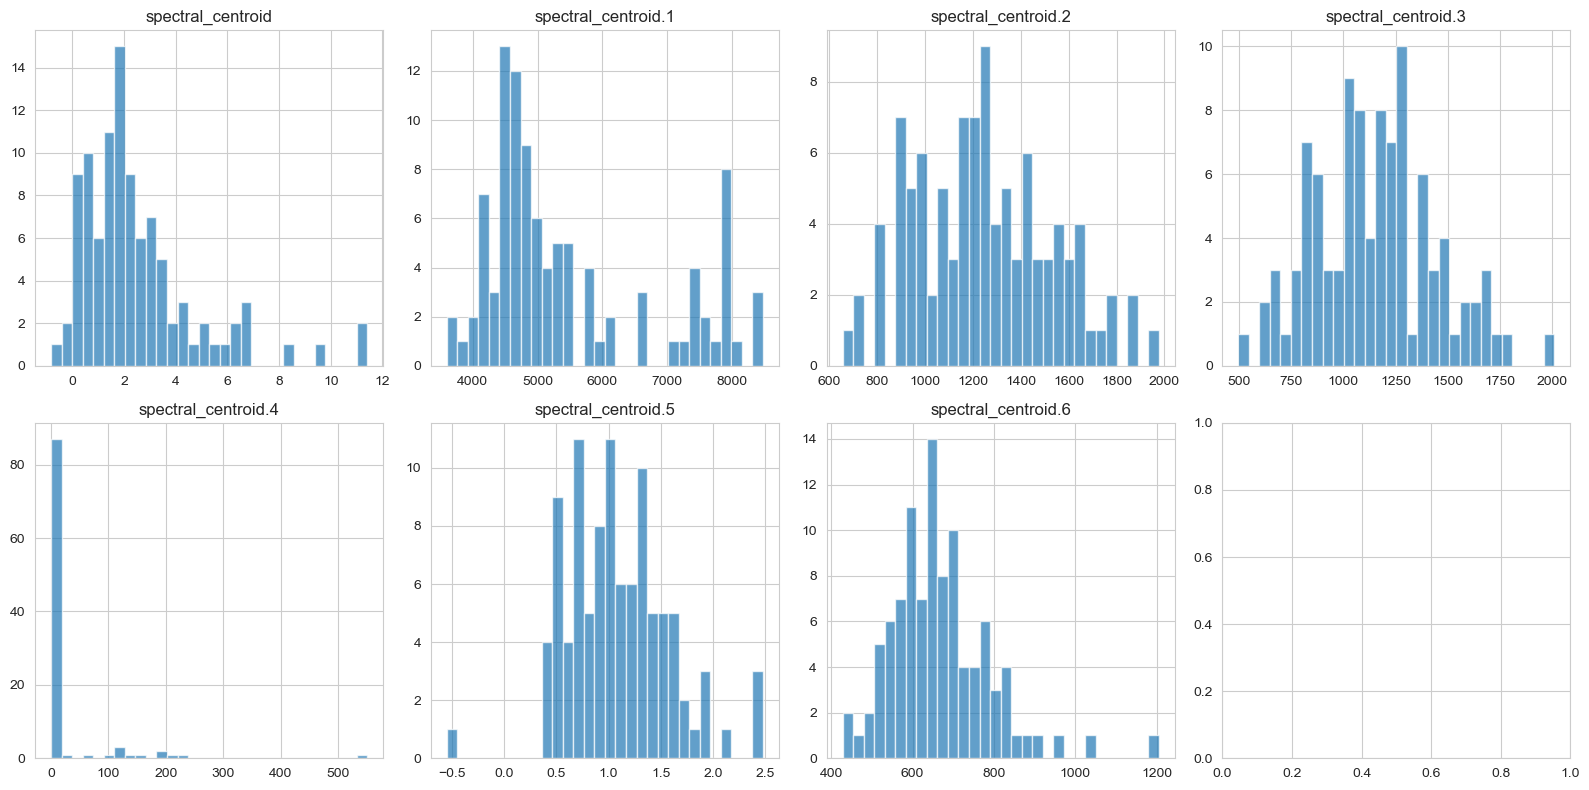

In [109]:
# Step 4: Visualization of Key Audio Features
# Distribution plots for spectral_centroid
if len(spectral_centroid_features) > 0:
    n_cols = min(4, len(spectral_centroid_features))
    n_rows = min(3, (len(spectral_centroid_features) + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(spectral_centroid_features[:n_rows*n_cols]):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(col)
    
    plt.tight_layout()
    plt.show()

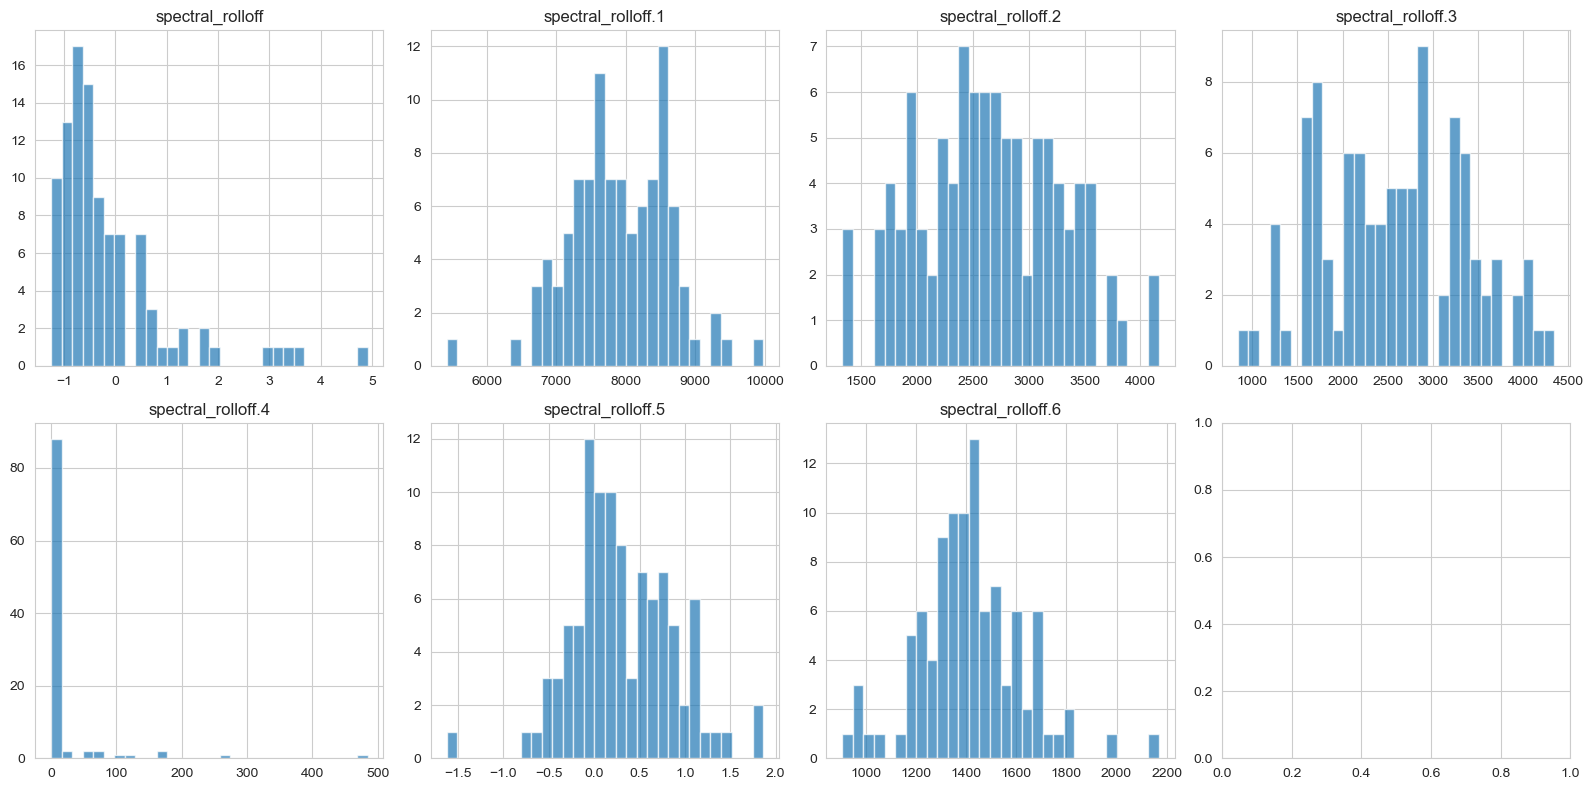

In [110]:
# Distribution plots for spectral_rolloff
if len(spectral_rolloff_features) > 0:
    n_cols = min(4, len(spectral_rolloff_features))
    n_rows = min(3, (len(spectral_rolloff_features) + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(spectral_rolloff_features[:n_rows*n_cols]):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(col)
    
    plt.tight_layout()
    plt.show()

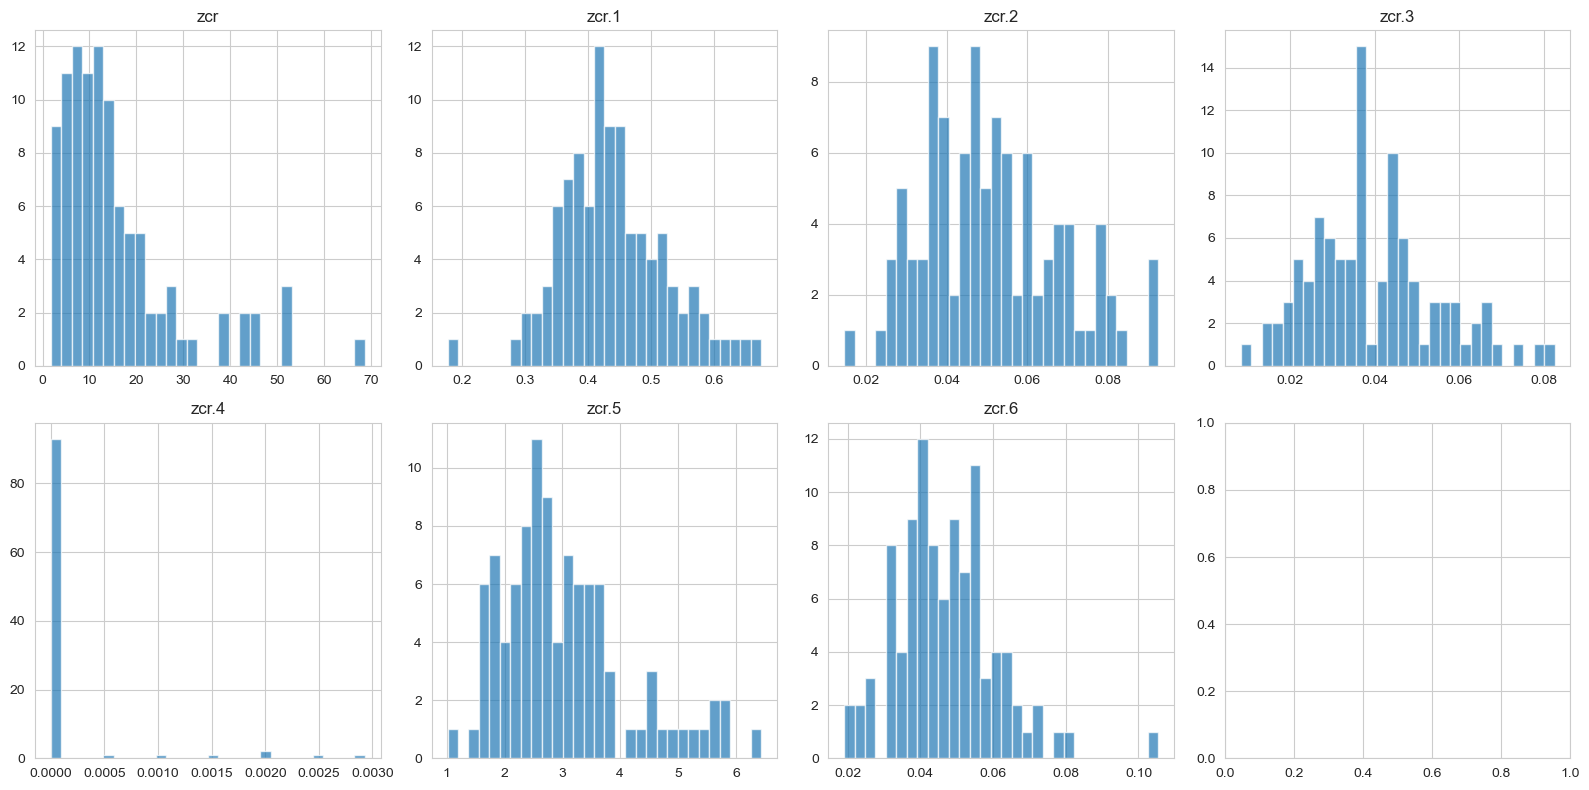

In [111]:
# Distribution plots for zcr
if len(zcr_features) > 0:
    n_cols = min(4, len(zcr_features))
    n_rows = min(3, (len(zcr_features) + n_cols - 1) // n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(zcr_features[:n_rows*n_cols]):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(col)
    
    plt.tight_layout()
    plt.show()

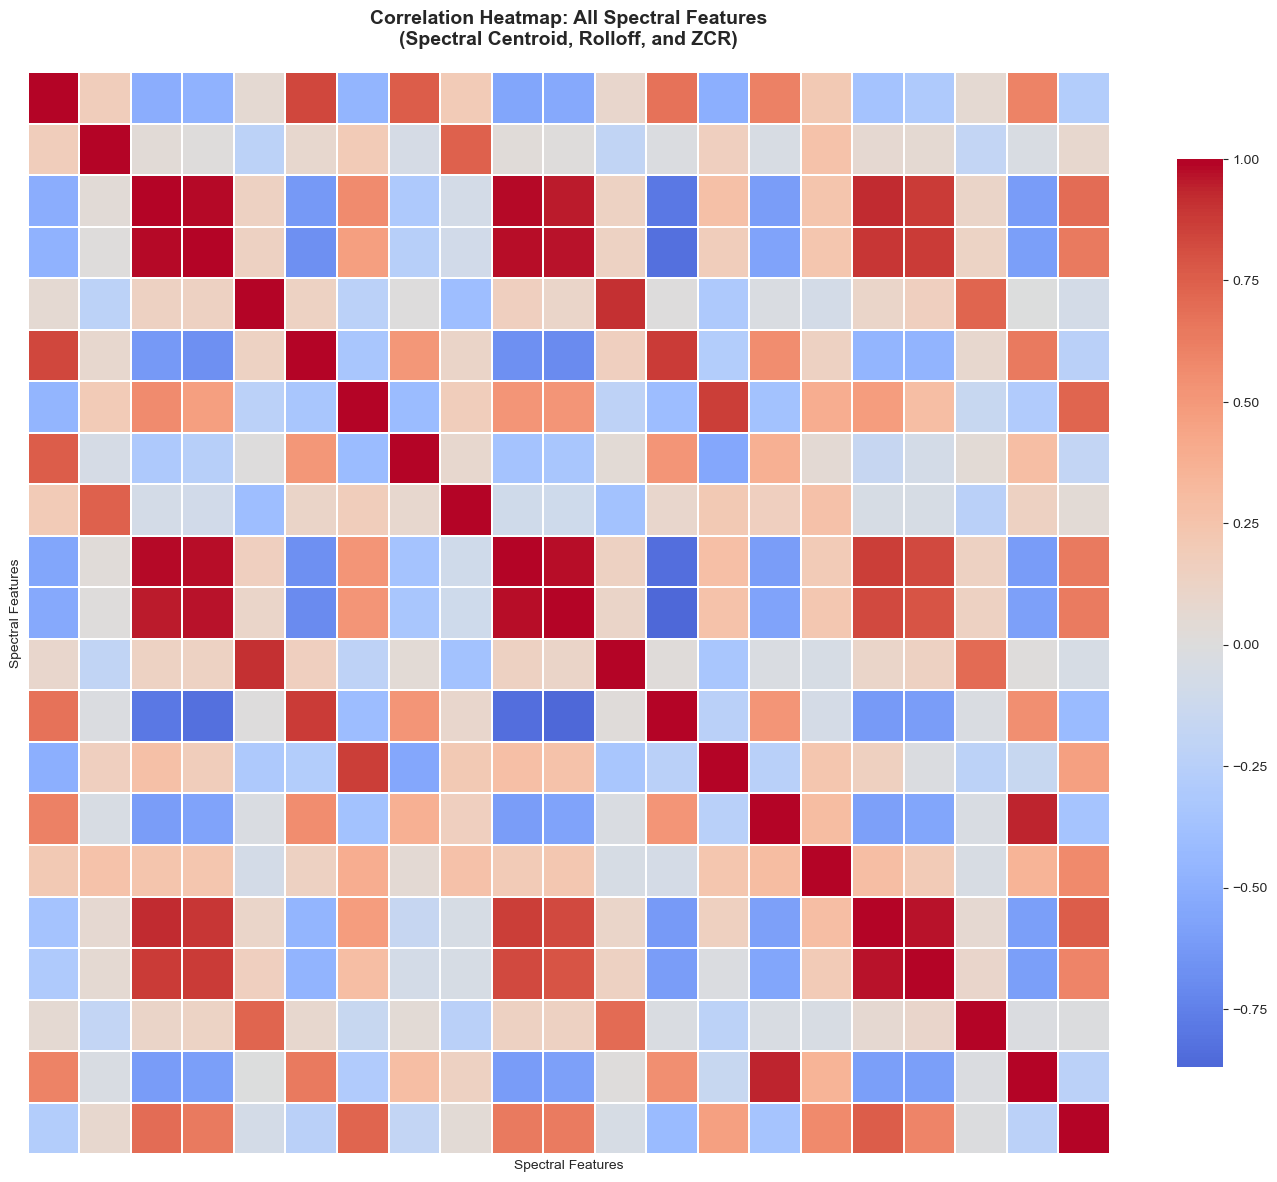

Correlation matrix shape: (21, 21)
Features included: 21


In [112]:
# Correlation heatmap among all selected spectral features
all_spectral_features = spectral_centroid_features + spectral_rolloff_features + zcr_features

if len(all_spectral_features) > 0:
    
    spectral_corr = df[all_spectral_features].corr()
    
    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        spectral_corr, 
        annot=False,  # Too many features to annotate
        cmap='coolwarm', 
        center=0,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8},
        xticklabels=False,  # Hide labels for readability
        yticklabels=False
    )
    plt.title(
        'Correlation Heatmap: All Spectral Features\n(Spectral Centroid, Rolloff, and ZCR)', 
        fontsize=14, fontweight='bold', pad=20
    )
    plt.xlabel("Spectral Features")
    plt.ylabel("Spectral Features")
    plt.tight_layout()
    plt.show()
    
    print(f"Correlation matrix shape: {spectral_corr.shape}")
    print(f"Features included: {len(all_spectral_features)}")
else:
    print("No spectral features found for correlation analysis")

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [113]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them